# VQA Annotations Quality Analysis

**Model:** Qwen2.5-VL-3B (via Ollama, Chat API)
**Dataset:** 10,000 memes (Telegram + Bing)

Objective: evaluate the quality of generated VQA annotations before building the search index.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

## 1. Data Loading

In [2]:
records = []
with open('../data/processed/vqa_annotations.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                continue

df = pd.DataFrame(records)
print(f'Total records: {len(df)}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Total records: 9998
Columns: ['filename', 'source_path', 'ocr_text', 'confidence', 'source_type', 'raw_response', 'caption', 'objects', 'tone', 'main_idea', 'max_5', 'key', 'max 5']


,filename,source_path,ocr_text,confidence,source_type,raw_response,caption,objects,tone,main_idea,max_5,key,max 5
0,cfc3b4e3fc05.jpg,data/raw/bing_memes/images/cfc3b4e3fc05.jpg,t your kids are atraid of the Dark... Make the...,0.9653,bing,"{""caption"": ""Meme features two baby doll image...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,535666cf1719.png,data/raw/telegram_stickers/Klubni4ka_by_fStikB...,,0.0000,telegram,NaN,A close-up of a cat with animated hearts and R...,"[cat, hearts, text]",humor,The image conveys an affectionate message to t...,NaN,NaN,NaN
2,79610c03db16.jpg,data/raw/bing_memes/images/79610c03db16.jpg,,0.0000,bing,NaN,A meme showing multiple people gathered around...,"[people, computer monitor, chairs, table, gamer]",humor,The image conveys that gamers are never alone ...,NaN,NaN,NaN


## 2. Dataset Overview

In [3]:
# Record Classification
df['has_caption'] = df['caption'].notna() & (df['caption'] != '')
df['has_all_fields'] = (
    df['has_caption'] & 
    df['tone'].notna() & 
    df['objects'].apply(lambda x: isinstance(x, list) and len(x) > 0) &
    df['main_idea'].notna()
)

# Records without caption but with raw_response
has_raw = 'raw_response' in df.columns
if has_raw:
    df['is_raw'] = df['raw_response'].notna() & ~df['has_caption']
else:
    df['is_raw'] = False

total = len(df)
full = int(df['has_all_fields'].sum())
cap_only = int(df['has_caption'].sum())
raw = int(df['is_raw'].sum())

print(f'Annotations Quality')
print(f'Total records:              {total}')
print(f'Full JSON (4 fields):     {full} ({full*100//total}%)')
print(f'With caption:                {cap_only} ({cap_only*100//total}%)')
print(f'Truncated (raw_response): {raw} ({raw*100//total}%)')
print()

# By sources
print('By Sources')
source_stats = df.groupby('source_type').agg(
    total=('filename', 'count'),
    with_caption=('has_caption', 'sum'),
    full_json=('has_all_fields', 'sum')
).reset_index()
source_stats['success_rate'] = (source_stats['with_caption'] / source_stats['total'] * 100).round(1)
display(source_stats)


Annotations Quality
Total records:              9998
Full JSON (4 fields):     9910 (99%)
With caption:                9915 (99%)
Truncated (raw_response): 83 (0%)

By Sources


,source_type,total,with_caption,full_json,success_rate
0,bing,4207,4141,4138,98.4
1,telegram,5791,5774,5772,99.7


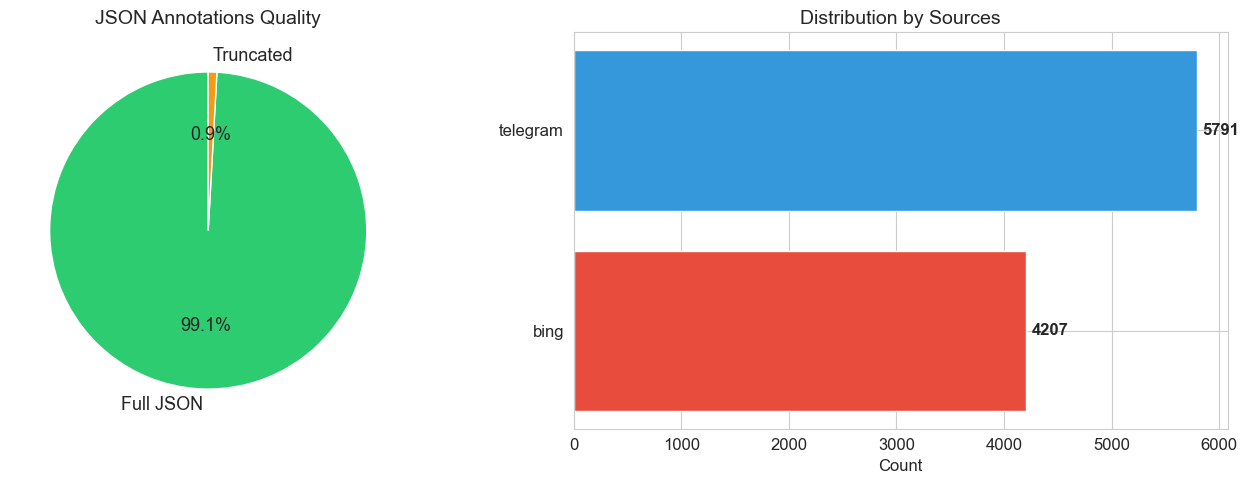

In [4]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie: quality
labels = ['Full JSON', 'Truncated']
sizes = [full, total - full]
colors = ['#2ecc71', '#f39c12']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 13})
axes[0].set_title('JSON Annotations Quality', fontsize=14)

# Bar: by sources
src_counts = df['source_type'].value_counts()
bars = axes[1].barh(src_counts.index[::-1], src_counts.values[::-1], color=['#3498db', '#e74c3c'][::-1])
axes[1].set_title('Distribution by Sources', fontsize=14)
axes[1].set_xlabel('Count')
for bar in bars:
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2.,
                f'{int(bar.get_width())}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/vqa_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Caption Length

Caption Stats
Mean length: 13.6 words (75 chars)
Median:       13 words
Min:           1 words
Max:          61 words


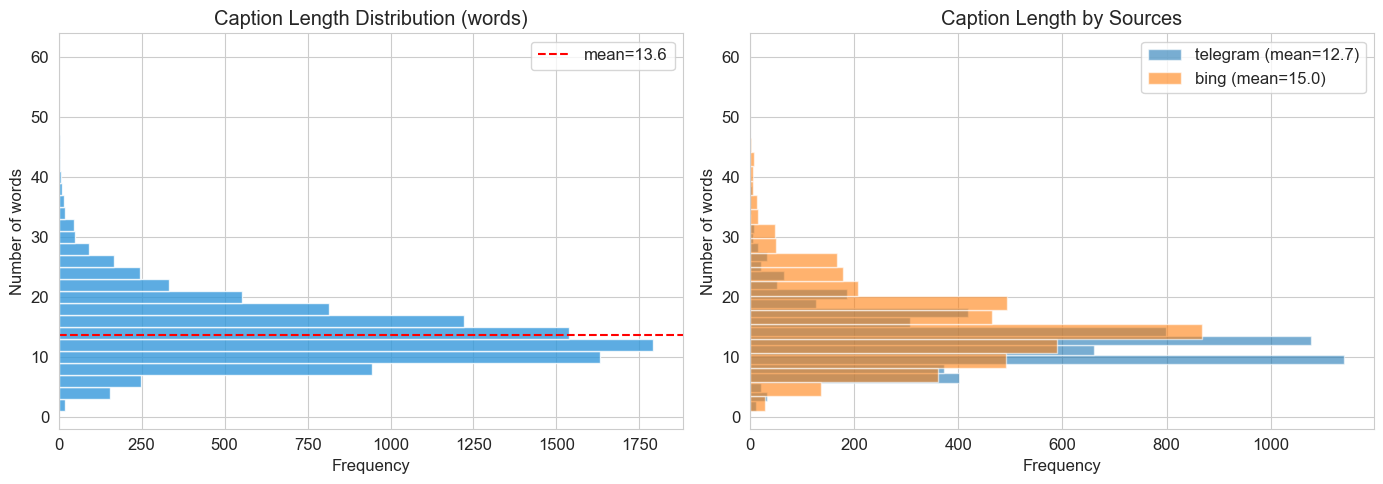

In [5]:
df_ok = df[df['has_caption']].copy()
df_ok['caption_words'] = df_ok['caption'].apply(lambda x: len(str(x).split()))
df_ok['caption_chars'] = df_ok['caption'].apply(lambda x: len(str(x)))

print(f'Caption Stats')
print(f'Mean length: {df_ok["caption_words"].mean():.1f} words ({df_ok["caption_chars"].mean():.0f} chars)')
print(f'Median:       {df_ok["caption_words"].median():.0f} words')
print(f'Min:           {df_ok["caption_words"].min()} words')
print(f'Max:          {df_ok["caption_words"].max()} words')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By words
axes[0].hist(df_ok['caption_words'], bins=30, alpha=0.8, color='#3498db', edgecolor='white', orientation='horizontal')
axes[0].axhline(df_ok['caption_words'].mean(), color='red', linestyle='--', label=f'mean={df_ok["caption_words"].mean():.1f}')
axes[0].set_ylabel('Number of words')
axes[0].set_xlabel('Frequency')
axes[0].set_title('Caption Length Distribution (words)')
axes[0].legend()

# By sources
for src in df_ok['source_type'].unique():
    subset = df_ok[df_ok['source_type'] == src]
    axes[1].hist(subset['caption_words'], bins=25, alpha=0.6, label=f'{src} (mean={subset["caption_words"].mean():.1f})', orientation='horizontal')
axes[1].set_ylabel('Number of words')
axes[1].set_xlabel('Frequency')
axes[1].set_title('Caption Length by Sources')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/caption_length.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Tone Distribution

Top-10 Tones
                      humor:  8024 (80%)
                    neutral:  1537 (15%)
              humor/sarcasm:   345 (3%)
                    support:     6 (0%)
                    unknown:     2 (0%)
                        hum:     1 (0%)


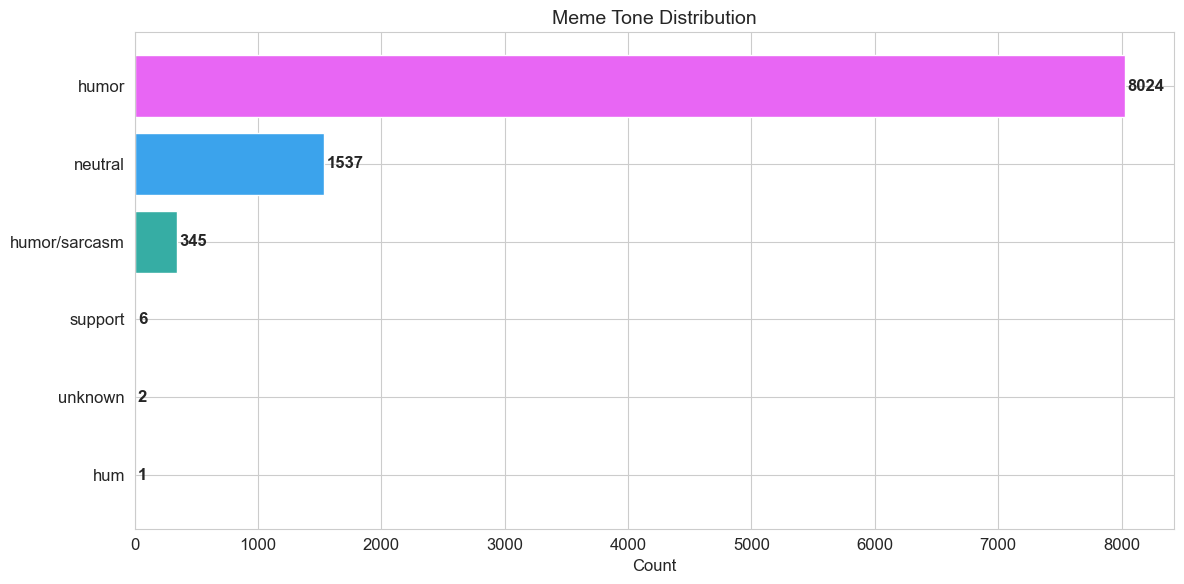

In [6]:
# Normalize tones (some models use /)
def normalize_tone(t):
    if pd.isna(t): return 'unknown'
    t = str(t).lower().strip()
    # If model returned variants separated by /, take the first one
    if '/' in t and len(t) > 20:
        t = t.split('/')[0].strip()
    return t

df_ok['tone_norm'] = df_ok['tone'].apply(normalize_tone)
tone_counts = df_ok['tone_norm'].value_counts().head(10)

print('Top-10 Tones')
for tone, count in tone_counts.items():
    print(f'  {tone:>25}: {count:>5} ({count*100//len(df_ok)}%)')

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('husl', len(tone_counts))
bars = ax.barh(tone_counts.index[::-1], tone_counts.values[::-1], color=colors)
ax.set_xlabel('Count')
ax.set_title('Meme Tone Distribution', fontsize=14)
for bar in bars:
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2.,
            f'{int(bar.get_width())}', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/tone_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Number of Objects per Meme

Objects Stats
Mean:  2.9 objects/meme
Median:  3
Max:     17


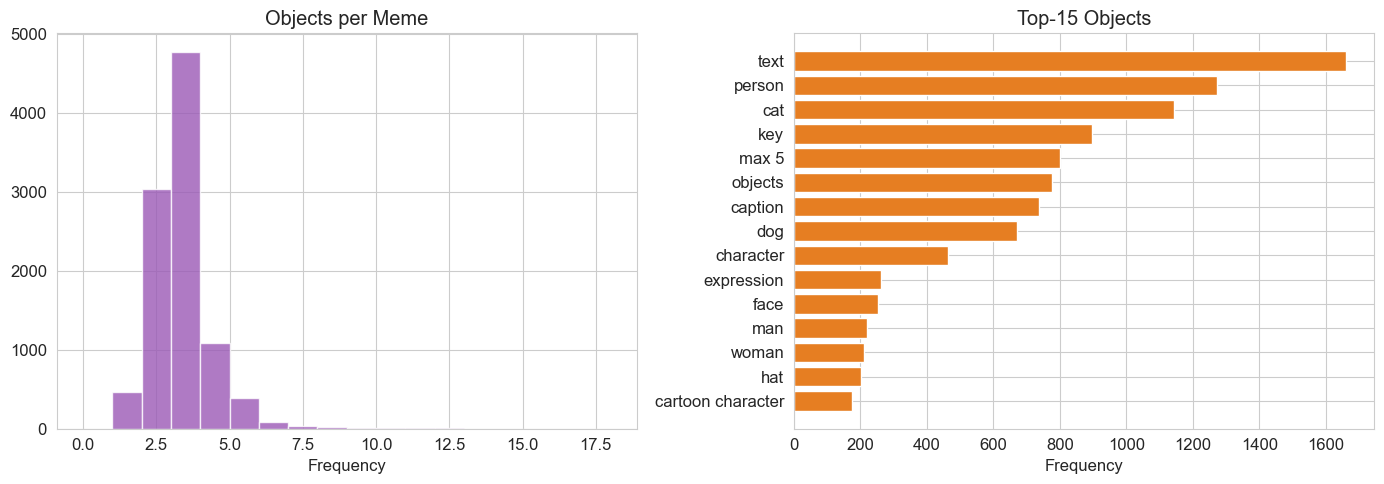

In [7]:
def count_objects(objs):
    if isinstance(objs, list):
        return len(objs)
    return 0

df_ok['n_objects'] = df_ok['objects'].apply(count_objects)

print(f'Objects Stats')
print(f'Mean:  {df_ok["n_objects"].mean():.1f} objects/meme')
print(f'Median:  {df_ok["n_objects"].median():.0f}')
print(f'Max:     {df_ok["n_objects"].max()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_ok['n_objects'], bins=range(0, df_ok['n_objects'].max()+2),
             alpha=0.8, color='#9b59b6', edgecolor='white')
axes[0].set_xlabel('Number of Objects')
axes[0].set_xlabel('Frequency')
axes[0].set_title('Objects per Meme')

# Most frequent objects
all_objects = []
for objs in df_ok['objects']:
    if isinstance(objs, list):
        all_objects.extend([str(o).lower().strip() for o in objs])
obj_freq = Counter(all_objects).most_common(15)
obj_names, obj_counts = zip(*obj_freq) if obj_freq else ([], [])

axes[1].barh(list(obj_names)[::-1], list(obj_counts)[::-1], color='#e67e22')
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top-15 Objects')

plt.tight_layout()
plt.savefig('../reports/objects_stats.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Annotation Examples

In [8]:
pd.set_option('display.max_colwidth', 100)

# Best examples
examples = df_ok[df_ok['has_all_fields']].sample(10, random_state=42)
display(examples[['filename', 'source_type', 'caption', 'tone', 'objects']].reset_index(drop=True))

,filename,source_type,caption,tone,objects
0,2fc5dede9f38.png,telegram,"A white puppy with devil horns and wings, adorned with a pentagram tattoo.",humor/sarcasm/critique/support/neutral/absurd,"[puppy, horns, wings, pentagram]"
1,72b7af8f3f8c.jpg,bing,A humorous trade offer where someone receives a hamburger today and another person receives mone...,humor/sarcasm/critique/support/neutral/absurd,"[trade offer, hamburger, money, Tuesday]"
2,e05909e32ec2.jpg,bing,A person in a blue and red jacket with a concerned expression.,humor/sarcasm/critique/support/neutral/absurd,"[person, jacket, expression]"
3,4933e9b3fac9.png,telegram,"Two figures are sitting at a table, one appears to be talking to the other, who is holding a cup.",humor/sarcasm/critique/support/neutral/absurd,"[table, chairs, cups, figures]"
4,7e65fedf8771.jpg,bing,A child in a superhero costume is celebrating a birthday cake.,humor/sarcasm/critique/support/neutral/absurd,"[cake, cake, max 5]"
5,3399f73ba41c.png,telegram,"The image features a split-colored bird with one half purple and the other yellow, and the text ...",humor/sarcasm/critique/support/neutral/absurd,"[bird, text]"
6,b2596a949f36.jpg,bing,Patrick Star is looking confused with a net in his mouth.,humor/sarcasm/critique/support/neutral/absurd,"[Patrick Star, net, mouth]"
7,b291d1aeecb8.png,telegram,The cat is wearing a blue hat and looking surprised.,humor/sarcasm/critique/support/neutral/absurd,"[cat, hat]"
8,6740a5f3546a.png,telegram,A black beetle with a humorous caption in Russian.,humor,[black beetle]
9,f0126f11c61b.jpg,bing,A person wearing headphones in a classroom setting.,humor/sarcasm/critique/support/neutral/absurd,"[headphones, person, classroom]"


## 7. Problematic Records

In [9]:
df_raw = df[df['is_raw']].copy()
print(f'Truncated records: {len(df_raw)}')

if len(df_raw) > 0:
    for i, (_, row) in enumerate(df_raw.head(5).iterrows()):
        raw = str(row.get('raw_response', ''))[:150]
        print(f'\n{i+1}. {row["filename"]} [{row["source_type"]}]')
        print(f'   Raw: {raw}...')

Truncated records: 83

1. cfc3b4e3fc05.jpg [bing]
   Raw: {"caption": "Meme features two baby doll images with glowing eyes and a yellow head, accompanied by text about making kids afraid of light.", "objects...

2. 564bbc72a8fc.jpg [bing]
   Raw: {"caption": "Meme depicting a person with a calculator despite math teachers' warnings. Features a whiteboard with mathematical equations.", "objects"...

3. 518761bab547.jpg [bing]
   Raw: {"caption": "Meme features a rainbow flag with arrows and text mocking 'okboomer' with 'okzoomer'....

4. 0f0a505279af.png [telegram]
   Raw: {"caption": "A man wearing a white sweatshirt forms a heart shape with his hands, displaying a visible arm tattoo.", "objects": ["man", "white sweatsh...

5. 727e1859dee9.jpg [bing]
   Raw: {"caption": "A stick figure holds a sign with repeated 'SOS' text while Russian text explains being denied going out by a parent.", "objects": ["stick...


## 8. Word Cloud (frequent words in caption)

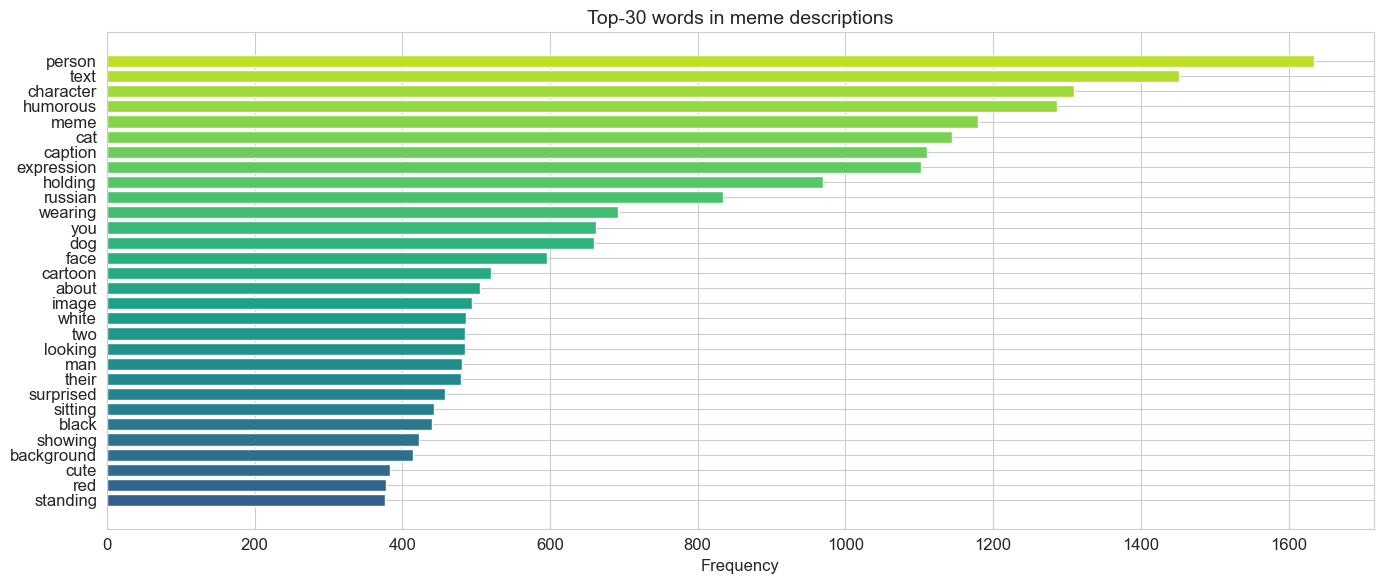

In [10]:
import re

# Collect all words from caption
stop_words = {'a', 'an', 'the', 'is', 'in', 'on', 'of', 'and', 'to', 'with', 'its', 'it',
              'that', 'this', 'for', 'are', 'as', 'at', 'by', 'from', 'or', 'be', 'has', 'was'}
all_words = []
for cap in df_ok['caption'].dropna():
    words = re.findall(r'[a-zA-Z]+', str(cap).lower())
    all_words.extend([w for w in words if w not in stop_words and len(w) > 2])

word_freq = Counter(all_words).most_common(30)

fig, ax = plt.subplots(figsize=(14, 6))
words, counts = zip(*word_freq)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(words)))
ax.barh(list(words)[::-1], list(counts)[::-1], color=colors)
ax.set_xlabel('Frequency')
ax.set_title('Top-30 words in meme descriptions', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary

In [11]:
# Recalculate inplace
_raw_count = len(df[~df['has_caption']])
_cap_count = len(df[df['has_caption']])


print('SUMMARY')
print(f'Model:                Qwen2.5-VL-3B')
print(f'Dataset:               {len(df)} memes')
print(f'  - Telegram:          {len(df[df["source_type"]=="telegram"])}')
print(f'  - Bing:              {len(df[df["source_type"]=="bing"])}')
print(f'Success rate:          {_cap_count*100/len(df):.1f}%')
print(f'Full JSON:           {df["has_all_fields"].sum()*100/len(df):.1f}%')
print(f'Mean caption length:     {df_ok["caption_words"].mean():.1f} words')
print(f'Mean objects/meme:      {df_ok["n_objects"].mean():.1f}')
print(f'Truncated:            {_raw_count} ({_raw_count*100/len(df):.1f}%)')
print('\nData is ready for building embeddings and search index.')


SUMMARY
Model:                Qwen2.5-VL-3B
Dataset:               9998 memes
  - Telegram:          5791
  - Bing:              4207
Success rate:          99.2%
Full JSON:           99.1%
Mean caption length:     13.6 words
Mean objects/meme:      2.9
Truncated:            83 (0.8%)

Data is ready for building embeddings and search index.
